## Here we plot some benchmark results. The benchmark were performed on Google Colab CPU or GPU (free tier) in order to be reproducible.

### Useful functions

In [1]:
from google.colab import drive
drive.mount('/content/gdrive', force_remount=True)
dir_parent = "/content/gdrive/MyDrive/KDExpress/src/"

Mounted at /content/gdrive


In [2]:
import time
import jax
jax.config.update("jax_enable_x64", True)
jax.config.update('jax_platform_name', 'gpu') # put 'gpu' here if you have one
import jax.numpy as jnp

import sys
sys.path.append(dir_parent)
from KDExpress import fft_kde1d, binned_kde1d, silverman_bw1d, build_hist_edges

def run_benchmark(func, func_args, func_kwargs, repetition=10):
  # warmuo
  func(*func_args, **func_kwargs)
  times = []
  for _ in range(repetition):
    t0 = time.time()
    res = func(*func_args, **func_kwargs).block_until_ready()
    tf = time.time()
    times.append(tf-t0)
  return jnp.mean(jnp.asarray(times)), jnp.std(jnp.asarray(times))

def jax_gkde_1d(points, data, weights, bw):
  return jax.scipy.stats.gaussian_kde(data,
                                      weights=weights,
                                      bw_method=bw
                                      )(points)

In [3]:
jax.devices()

[CudaDevice(id=0)]

# Univariate case

## 1. Compute everything within KDE FFT

In [4]:
key = jax.random.PRNGKey(42)
data_1d = jax.random.normal(key, shape=(10_000,))
weights = data_1d**2
points_1d = jnp.linspace(jnp.min(data_1d)-0.5, jnp.max(data_1d)-0.5, 500)

fft_kde_1d_args = [points_1d, data_1d]
fft_kde_1d_kwargs = {'weights': weights}

binned_kde_1d_args = [points_1d, data_1d]
binned_kde_1d_kwargs = {'weights': weights, 'nbins':200}

jax_kde_args = [points_1d, data_1d, weights, silverman_bw1d(data_1d)]
jax_kde_kwargs = {}

# Run the following on Colab for consistency
print(run_benchmark(fft_kde1d, fft_kde_1d_args, fft_kde_1d_kwargs))
print(run_benchmark(binned_kde1d, binned_kde_1d_args, binned_kde_1d_kwargs))
print(run_benchmark(jax_gkde_1d, jax_kde_args, jax_kde_kwargs))

(Array(0.00118022, dtype=float64), Array(0.00078613, dtype=float64))
(Array(0.0010709, dtype=float64), Array(0.0001371, dtype=float64))
(Array(0.00621002, dtype=float64), Array(0.00016008, dtype=float64))


## 2. Precompute bin_edges (useful when the grid is fixed)

In [5]:
be = build_hist_edges(data_1d)
fft_kde_1d_args_2 = [points_1d, data_1d]
fft_kde_1d_kwargs_2 = {'weights': weights, 'bin_edges':be}

# Run the following on Colab for consistency
print(run_benchmark(fft_kde1d, fft_kde_1d_args, fft_kde_1d_kwargs))

(Array(0.0009726, dtype=float64), Array(0.00014085, dtype=float64))


## 3. Case in which points have support much wider than data

In [6]:
points_1d_wide = jnp.linspace(jnp.min(data_1d)-5*jnp.std(data_1d), jnp.max(data_1d)+5*jnp.std(data_1d), 500)
be = build_hist_edges(points_1d_wide)

fft_kde_1d_args = [points_1d_wide, data_1d]
fft_kde_1d_kwargs = {'weights': weights}
fft_kde_1d_kwargs_with_be = {'weights': weights, 'bin_edges':be}

binned_kde_1d_args = [points_1d_wide, data_1d]
binned_kde_1d_kwargs_no_cut = {'weights': weights, 'nbins':200,}
binned_kde_1d_kwargs_with_cut = {'weights': weights, 'nbins':200, 'cut_sigma_data':2}

jax_kde_args = [points_1d, data_1d, weights, silverman_bw1d(data_1d)]
jax_kde_kwargs = {}

# Run the following on Colab for consistency
print(run_benchmark(fft_kde1d, fft_kde_1d_args, fft_kde_1d_kwargs))
print(run_benchmark(fft_kde1d, fft_kde_1d_args, fft_kde_1d_kwargs_with_be))
print(run_benchmark(binned_kde1d, binned_kde_1d_args, binned_kde_1d_kwargs_no_cut))
print(run_benchmark(binned_kde1d, binned_kde_1d_args, binned_kde_1d_kwargs_with_cut))
print(run_benchmark(jax_gkde_1d, jax_kde_args, jax_kde_kwargs))

(Array(0.00098448, dtype=float64), Array(0.00014996, dtype=float64))
(Array(0.00092087, dtype=float64), Array(3.85429572e-05, dtype=float64))
(Array(0.00109608, dtype=float64), Array(0.00016377, dtype=float64))
(Array(0.0013171, dtype=float64), Array(7.83684481e-05, dtype=float64))
(Array(0.00636294, dtype=float64), Array(0.00013174, dtype=float64))


# 4. Varying points resolution

In [7]:
from collections import defaultdict

key = jax.random.PRNGKey(42)
data_1d = jax.random.normal(key, shape=(10_000,))
weights = data_1d**2

fft_kde_1d_args = [points_1d, data_1d]
fft_kde_1d_kwargs = {'weights': weights}

binned_kde_1d_args = [points_1d, data_1d]
binned_kde_1d_kwargs = {'weights': weights, 'nbins':200,}

jax_kde_args = [points_1d, data_1d, weights, silverman_bw1d(data_1d)]
jax_kde_kwargs = {}

methods = {
  'fft_kde': (fft_kde1d, fft_kde_1d_args, fft_kde_1d_kwargs),
  'binned_kde': (binned_kde1d, binned_kde_1d_args, binned_kde_1d_kwargs),
  'jax_kde': (jax_gkde_1d, jax_kde_args, jax_kde_kwargs)
}

def compute_benchmark_point_res(points_res):
  mean_times = defaultdict(list)
  for res in points_res:
    points_1d = jnp.linspace(jnp.min(data_1d)-0.5, jnp.max(data_1d)+0.5, res)
    be = build_hist_edges(points_1d)
    fft_kde_1d_args[0] = points_1d
    binned_kde_1d_args[0] = points_1d
    jax_kde_args[0] = points_1d

    fft_kde_1d_kwargs_with_be['bin_edges'] = be

    print(f"\nResolution: {res} points")
    for method_name, (func, args, kwargs) in methods.items():
      mean, std = run_benchmark(func, args, kwargs)
      mean_times[method_name].append(float(mean))
      print(f"{method_name}: {mean:.5f} ± {std:.5f} s")
  return dict(mean_times)

points_res = [200,400,600,800,1000]
mean_times_point_res = compute_benchmark_point_res(points_res)


Resolution: 200 points
fft_kde: 0.00091 ± 0.00003 s
binned_kde: 0.00100 ± 0.00010 s
jax_kde: 0.00576 ± 0.00164 s

Resolution: 400 points
fft_kde: 0.00093 ± 0.00004 s
binned_kde: 0.00108 ± 0.00014 s
jax_kde: 0.00569 ± 0.00015 s

Resolution: 600 points
fft_kde: 0.00093 ± 0.00001 s
binned_kde: 0.00104 ± 0.00015 s
jax_kde: 0.00678 ± 0.00016 s

Resolution: 800 points
fft_kde: 0.00097 ± 0.00008 s
binned_kde: 0.00114 ± 0.00012 s
jax_kde: 0.00789 ± 0.00015 s

Resolution: 1000 points
fft_kde: 0.00100 ± 0.00003 s
binned_kde: 0.00120 ± 0.00016 s
jax_kde: 0.00918 ± 0.00029 s


# 5. Varying sample resolution

In [8]:
fft_kde_1d_args = [points_1d, data_1d]
fft_kde_1d_kwargs = {'weights': weights}

binned_kde_1d_args = [points_1d, data_1d]
binned_kde_1d_kwargs = {'weights': weights, 'nbins':200,}

jax_kde_args = [points_1d, data_1d, weights, silverman_bw1d(data_1d)]
jax_kde_kwargs = {}

methods = {
  'fft_kde': (fft_kde1d, fft_kde_1d_args, fft_kde_1d_kwargs),
  'binned_kde': (binned_kde1d, binned_kde_1d_args, binned_kde_1d_kwargs),
  'jax_kde': (jax_gkde_1d, jax_kde_args, jax_kde_kwargs)
}

def compute_benchmark_data_res(data_res):
  mean_times = defaultdict(list)
  for res in data_res:
    key = jax.random.PRNGKey(42)
    data_1d = jax.random.normal(key, shape=(res,))
    weights = data_1d**2
    points_1d = jnp.linspace(jnp.min(data_1d)-0.5, jnp.max(data_1d)+0.5, 500)
    be = build_hist_edges(points_1d)

    fft_kde_1d_args[0] = points_1d
    binned_kde_1d_args[0] = points_1d
    fft_kde_1d_args[1] = data_1d
    binned_kde_1d_args[1] = data_1d

    fft_kde_1d_kwargs['weights'] = weights
    binned_kde_1d_kwargs['weights'] = weights
    fft_kde_1d_kwargs_with_be['weights'] = weights
    fft_kde_1d_kwargs_with_be['bin_edges'] = be

    jax_kde_args[0] = points_1d
    jax_kde_args[1] = data_1d
    jax_kde_args[2] = weights
    jax_kde_args[3] = silverman_bw1d(data_1d)


    print(f"\nResolution: {res} samples")
    for method_name, (func, args, kwargs) in methods.items():
      mean, std = run_benchmark(func, args, kwargs)
      mean_times[method_name].append(float(mean))
      print(f"{method_name}: {mean:.5f} ± {std:.5f} s")
  return dict(mean_times)

data_res = [ 5_000, 7_500, 10_000, 12_500, 15_000]
mean_times_data_res = compute_benchmark_data_res(data_res)


Resolution: 5000 samples
fft_kde: 0.00123 ± 0.00118 s
binned_kde: 0.00089 ± 0.00009 s
jax_kde: 0.00485 ± 0.00018 s

Resolution: 7500 samples
fft_kde: 0.00082 ± 0.00002 s
binned_kde: 0.00094 ± 0.00012 s
jax_kde: 0.00550 ± 0.00007 s

Resolution: 10000 samples
fft_kde: 0.00098 ± 0.00023 s
binned_kde: 0.00115 ± 0.00019 s
jax_kde: 0.00661 ± 0.00048 s

Resolution: 12500 samples
fft_kde: 0.00096 ± 0.00003 s
binned_kde: 0.00111 ± 0.00009 s
jax_kde: 0.01120 ± 0.00193 s

Resolution: 15000 samples
fft_kde: 0.00099 ± 0.00003 s
binned_kde: 0.00121 ± 0.00014 s
jax_kde: 0.00807 ± 0.00024 s


# Final plots

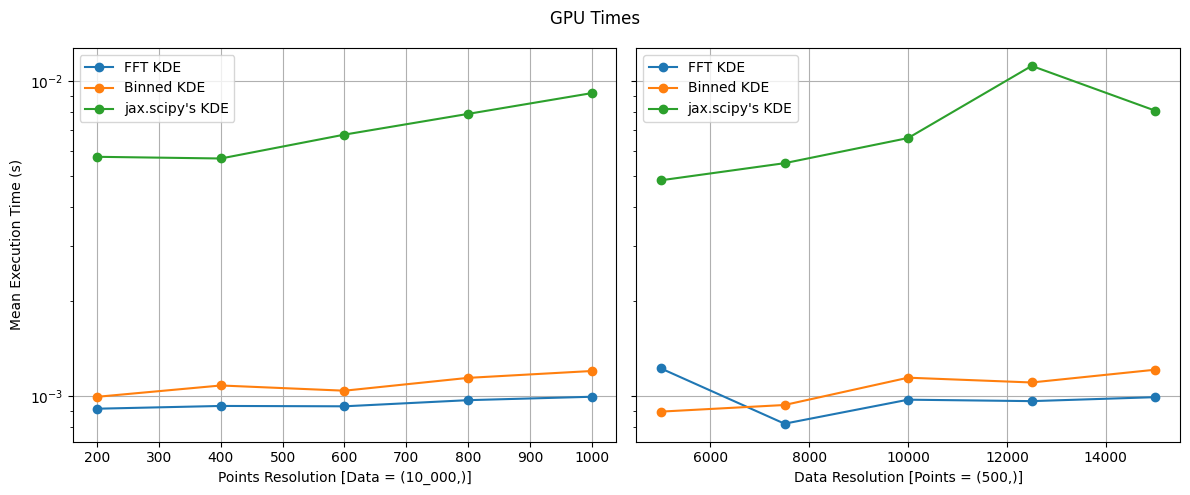

In [10]:
import matplotlib.pyplot as plt

# Create a figure with two subplots side by side with shared y-axis
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

labels = {'fft_kde': 'FFT KDE',
          'binned_kde': 'Binned KDE',
          'jax_kde':"jax.scipy's KDE"}

# First subplot - Points Resolution
for method in methods:
    ax1.plot(points_res, mean_times_point_res[method], marker='o', label=labels[method])
ax1.set_xlabel('Points Resolution [Data = (10_000,)]')
ax1.set_ylabel('Mean Execution Time (s)')
ax1.set_yscale('log')
#ax1.set_ylim(1e-3, 5e-1)
ax1.legend()
ax1.grid(True)

# Second subplot - Data Resolution
for method in methods:
    ax2.plot(data_res, mean_times_data_res[method], marker='o', label=labels[method])
ax2.set_xlabel('Data Resolution [Points = (500,)]')
ax2.legend()
ax2.grid(True)

fig.suptitle('GPU Times')
plt.tight_layout()
plt.savefig(dir_parent+'../examples/gpu_bench_1d.png', dpi=600)
plt.show()